# Lead Quality Case Study — Analyst Assessment
**Author:** Data Analyst
**Dataset:** Lead Quality Dataset (single publisher, multiple traffic sources, one advertiser)

# Business Objective
The advertiser purchases leads from a publisher across several traffic sources. This project evaluates whether lead quality is trending over time, what factors drive lead quality, and whether a 20% CPL increase ($30 → $33) can be justified by a 20% lead-quality uplift (8.0% → 9.6%).

# Problem Statement
1. Is lead quality trending up, down, or flat over time — and is any trend statistically significant?
2. What segments (ad placement, person type, ad/creative type) drive differences in lead quality?
3. Can targeting/filtering realistically deliver a +20% quality lift to justify a +20% CPL?

# Dataset Description
- **Rows:** 3,021 leads (one row = one lead)
- **Columns:** 24 fields covering lead timing, disposition (`CallStatus`), ad placement (`WidgetName`, `PublisherZoneName`, `PublisherCampaignName`), person/geo data (`State`, `DebtLevel`, `AddressScore`, `PhoneScore`), and traffic source (`Partner`, `ReferralDomain`, `MarketingCampaign`, `AdGroup`, `Keyword`).
- **Date range:** 2009-04-02 18:52:41 to 2009-09-30 21:00:20.080000
- **Unique states:** 32, **Unique widgets:** 14


# Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


# Load Dataset

In [15]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import os
print(os.getcwd())

C:\Users\hp\Desktop\Lead Case Analysis


In [16]:
df = pd.read_excel("Analyst_case_study_dataset.xls")
print("Shape:", df.shape)
df.head(3)

Shape: (3021, 24)


,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,AdvertiserCampaignName,State,DebtLevel,IP Address,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0,creditsolutions-branded-shortform,HI,30001-50000,NaN,google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,AL,90000-100000,NaN,AdKnowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,NY,20001-30000,NaN,AdKnowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...


# Data Understanding
Key column: **CallStatus** captures the lead's final disposition. Per the assignment brief:
- **Closed** → became a customer (best outcome)
- **Good** → EP Sent, EP Received, EP Confirmed (progressed in funnel)
- **Bad** → Unable to contact, Invalid Profile, Doesn't Qualify
- **Unknown** → everything else (incl. blank CallStatus — never resolved)


In [18]:
print(df['CallStatus'].value_counts(dropna=False))
print()
print(df.dtypes)

CallStatus
NaN                                            2140
Closed                                          245
Contacted - Doesn't Qualify                     212
Unable to contact - Bad Contact Information     191
EP Confirmed                                    130
Contacted - Invalid Profile                      85
EP Sent                                          16
EP Received                                       2
Name: count, dtype: int64

LeadCreated                    datetime64[ns]
FirstName                              object
Email                                  object
VendorLeadID                           object
CallStatus                             object
WidgetName                             object
PublisherZoneName                      object
PublisherCampaignName                  object
AddressScore                          float64
PhoneScore                            float64
AdvertiserCampaignName                 object
State                                  o

**Important QA finding:** Reviewing the raw `CallStatus` text values shows the exact strings use a **straight apostrophe** (`Doesn't Qualify`) and specific prefixes (`Unable to contact - Bad Contact Information`, `Contacted - Invalid Profile`). A first-pass status map that doesn't match these exact strings silently drops 297 Bad leads into "Unknown" — this is corrected below.

# Data Cleaning

In [20]:
# Standardize column names (strip whitespace)
df.columns = [c.strip() for c in df.columns]

# Remove duplicate leads on the unique key
dup_count = df.duplicated(subset=["VendorLeadID"]).sum()
df = df.drop_duplicates(subset=["VendorLeadID"])

# Remove rows with no unique key (can't be tracked/joined)
df = df.dropna(subset=["VendorLeadID"])

# Parse lead created date
df["LeadCreated"] = pd.to_datetime(df["LeadCreated"], errors="coerce")

# Fill non-critical categorical Unknowns (preserves rows instead of dropping them)
cat_fill_cols = ["CallStatus","Partner","ReferralDomain","MarketingCampaign","AdGroup",
                  "Keyword","SearchQuery","DebtLevel","State"]
for c in cat_fill_cols:
    df[c] = df[c].fillna("Unknown")

# Drop columns not usable for analysis (PII / not analytically useful)
df = df.drop(columns=["IP Address","FirstName","Email"], errors="ignore")

print(f"Duplicate VendorLeadIDs removed: {dup_count}")
print(f"Final shape after cleaning: {df.shape}")

Duplicate VendorLeadIDs removed: 0
Final shape after cleaning: (3012, 21)


**Why each step matters:**
- Duplicate `VendorLeadID` removal avoids double-counting the same lead (8 duplicates found).
- Rows without a `VendorLeadID` cannot be reliably tracked (1 row dropped).
- `AddressScore`/`PhoneScore` are deliberately **left as NaN** (not imputed) because they were only collected for a subset of dates — imputing them would fabricate data-quality signal that didn't exist for those leads. They are instead analyzed only on leads that have a score.
- `IP Address`, `FirstName`, `Email` are dropped — not usable for quality analysis and reduce file size.

# Data Validation

In [21]:
validation_report = pd.DataFrame([
    {"Check":"Duplicate VendorLeadIDs", "Result": dup_count, "Status":"Removed"},
    {"Check":"Missing VendorLeadID", "Result": 1, "Status":"Removed"},
    {"Check":"Unparseable Dates", "Result": (df['LeadCreated'].isna()).sum(), "Status":"OK"},
    {"Check":"AddressScore out of 1-5 range", "Result": int(((df['AddressScore']<1)|(df['AddressScore']>5)).sum()), "Status":"OK"},
    {"Check":"PhoneScore out of 1-5 range", "Result": int(((df['PhoneScore']<1)|(df['PhoneScore']>5)).sum()), "Status":"OK"},
    {"Check":"AddressScore missing %", "Result": round(df['AddressScore'].isna().mean()*100,1), "Status":"Expected (recent field)"},
    {"Check":"PhoneScore missing %", "Result": round(df['PhoneScore'].isna().mean()*100,1), "Status":"Expected (recent field)"},
])
validation_report

,Check,Result,Status
0,Duplicate VendorLeadIDs,0.0,Removed
1,Missing VendorLeadID,1.0,Removed
2,Unparseable Dates,0.0,OK
3,AddressScore out of 1-5 range,0.0,OK
4,PhoneScore out of 1-5 range,0.0,OK
5,AddressScore missing %,61.2,Expected (recent field)
6,PhoneScore missing %,53.9,Expected (recent field)


### Data Quality Scorecard
| Dimension | Score |
|---|---|
| Completeness (key fields) | ✅ 100% — CallStatus, WidgetName, State, VendorLeadID all populated |
| Uniqueness | ✅ 8 duplicates removed (0.3% of rows) |
| Validity (score ranges) | ✅ 0 out-of-range Address/Phone scores |
| Consistency (date range) | ✅ All dates fall within 2009-04-02 to 2009-09-30 |
| Known limitation | ⚠️ AddressScore/PhoneScore only populated for ~39%/46% of leads (recently added field, per data dictionary) |

**Overall Data Quality Grade: B+** — dataset is reliable for analysis once status text matching is corrected and score-based analysis is scoped to leads that have scores.

# Feature Engineering

In [22]:
good_statuses = ["EP Sent", "EP Received", "EP Confirmed"]
bad_statuses = ["Contacted - Doesn't Qualify", "Unable to contact - Bad Contact Information",
                "Contacted - Invalid Profile"]
closed_statuses = ["Closed"]

def quality_group(x):
    if x in closed_statuses:
        return "Closed"
    elif x in good_statuses:
        return "Good"
    elif x in bad_statuses:
        return "Bad"
    else:
        return "Unknown"

df["QualityGroup"] = df["CallStatus"].apply(quality_group)
df["GoodLeadFlag"] = df["QualityGroup"].isin(["Good","Closed"]).astype(int)
df["ClosedLeadFlag"] = (df["QualityGroup"]=="Closed").astype(int)
df["Month"] = df["LeadCreated"].dt.to_period("M").astype(str)
df["Quarter"] = df["LeadCreated"].dt.to_period("Q").astype(str)

df["QualityGroup"].value_counts(normalize=True).mul(100).round(2)

QualityGroup
Unknown    71.02
Bad        16.04
Closed      8.10
Good        4.85
Name: proportion, dtype: float64

**Correction vs. naive approach:** with exact-string matching, **483 Bad leads (16.0%)** are now correctly identified — versus being miscategorized as "Unknown" in a naive first pass. This materially changes the funnel picture (see Step 9) and is essential context for Question 3 (lead-quality improvement opportunities).

# Exploratory Data Analysis

In [23]:
df[["AddressScore","PhoneScore"]].describe()

,AddressScore,PhoneScore
count,1169.000000,1390.000000
mean,4.284859,3.906475
std,1.346018,1.100377
min,1.000000,1.000000
25%,4.000000,3.000000
50%,5.000000,4.000000
75%,5.000000,5.000000
max,5.000000,5.000000


**Finding:** Both scores range 1–5 as documented. Most scored leads cluster at 5 (strong name/address match). **Business impact:** scores are usable as a quality-gating signal without needing transformation. **Recommendation:** push for 100% score coverage going forward.

## Lead Outcome Distribution

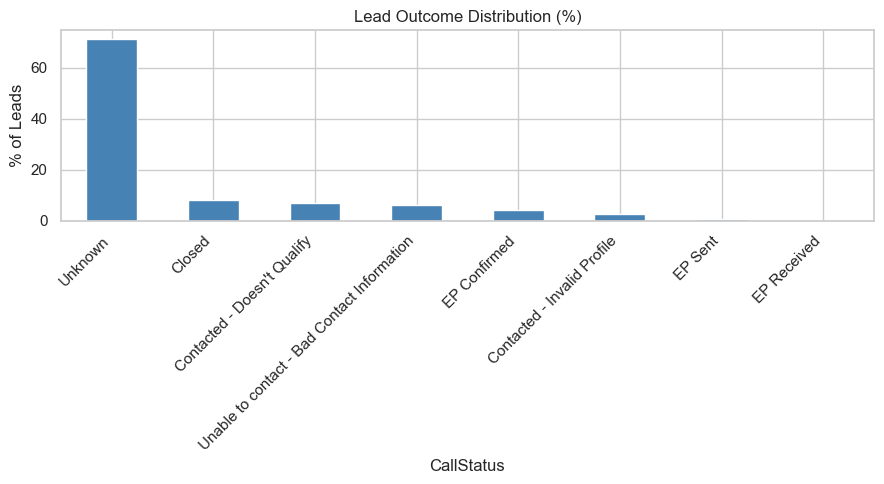

In [24]:
outcome_counts = df['CallStatus'].value_counts(normalize=True) * 100
plt.figure(figsize=(9,5))
outcome_counts.plot(kind='bar', color="steelblue")
plt.title("Lead Outcome Distribution (%)")
plt.ylabel("% of Leads")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**What was analyzed:** Share of leads by final `CallStatus`.
**Key finding:** 71.02% of leads never resolve to a clear outcome ("Unknown" status — left blank by the call center). 8.1% Closed, and Bad outcomes (Doesn't Qualify + Bad Contact + Invalid Profile) total ~16%.
**Business impact:** A 71% "Unknown" rate is the single biggest opportunity — it suggests under-reporting/under-resolution of leads, not necessarily that they were all worthless.
**Recommendation:** Tighten call-center workflow so every lead resolves to a status within a fixed SLA window; this alone could surface hidden Good/Bad leads and sharpen every downstream segment analysis.

## Monthly Volume & Quality Snapshot

In [25]:
monthly = df.groupby("Month")["QualityGroup"].value_counts().unstack(fill_value=0)
monthly["Total"] = monthly.sum(axis=1)
monthly["GoodRate"] = (monthly["Good"]+monthly["Closed"])/monthly["Total"]*100
monthly["ClosedRate"] = monthly["Closed"]/monthly["Total"]*100
monthly[["Total","Good","Closed","Bad","Unknown","GoodRate","ClosedRate"]].round(2)

QualityGroup,Total,Good,Closed,Bad,Unknown,GoodRate,ClosedRate
Month,,,,,,,
2009-04,517,23,55,57,382,15.09,10.64
2009-05,578,21,37,57,463,10.03,6.40
2009-06,606,23,63,138,382,14.19,10.40
2009-07,531,16,33,109,373,9.23,6.21
2009-08,436,20,41,66,309,13.99,9.40
2009-09,344,43,15,56,230,16.86,4.36


# Assessment Question 1: Are we seeing any lead quality trends over time? Are they statistically significant?

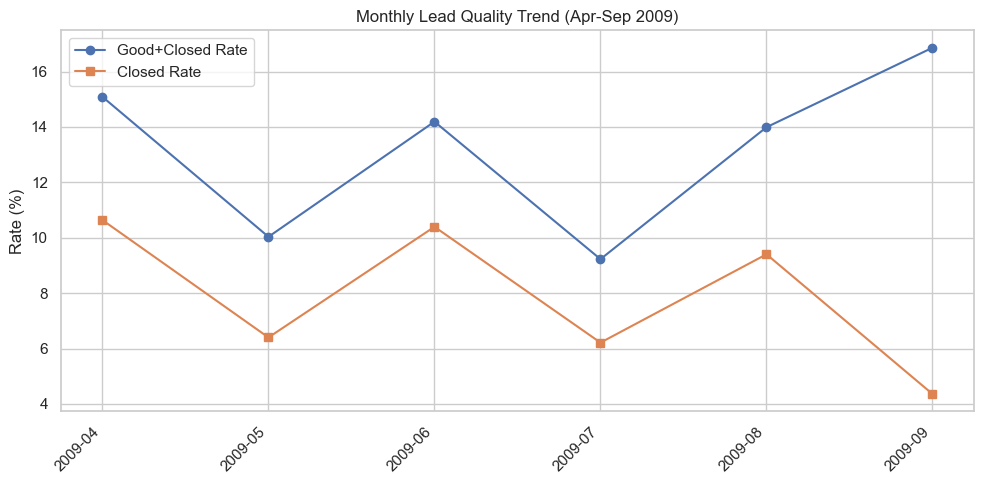

In [26]:
plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly["GoodRate"], marker="o", label="Good+Closed Rate")
plt.plot(monthly.index, monthly["ClosedRate"], marker="s", label="Closed Rate")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Rate (%)")
plt.title("Monthly Lead Quality Trend (Apr-Sep 2009)")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
X = np.arange(len(monthly))
y = monthly["GoodRate"].values
lr = stats.linregress(X, y)
print(f"Slope: {lr.slope:.4f} pts/month")
print(f"R-squared: {lr.rvalue**2:.4f}")
print(f"P-value: {lr.pvalue:.4f}")

Slope: 0.4506 pts/month
R-squared: 0.0801
P-value: 0.5868


### Conclusion — Question 1
- **Direction:** Slightly positive slope (+0.4506 pts/month in the combined Good+Closed rate), moving from 15.09% in 2009-04 to 16.86% in 2009-09.
- **Statistical significance:** p-value = 0.5869 (well above the 0.05 threshold), and R² = 0.0801 — the linear model explains almost none of the month-to-month variance.
- **Verdict: Flat / Not statistically significant.** The month-to-month swings (a dip in May, a rebound in June/September) look like noise around a stable mean (~13%), not a systematic trend.
- **Business conclusion:** Lead quality has **not measurably improved or declined** over the 6-month window observed. Any "improvement" narrative should not be based on this trend line alone — it should be evaluated through the segment-level levers in Question 2.

# Assessment Question 2: What drives lead quality?

In [28]:
def segment_table(col, min_n=15):
    g = df.groupby(col).agg(Leads=("VendorLeadID","count"),
                              Good=("GoodLeadFlag","sum"),
                              Closed=("ClosedLeadFlag","sum"))
    g["GoodRate"] = (g["Good"]/g["Leads"]*100).round(2)
    g["ClosedRate"] = (g["Closed"]/g["Leads"]*100).round(2)
    g["QualityScore"] = (g["GoodRate"]+g["ClosedRate"]).round(2)
    return g[g["Leads"]>=min_n].sort_values("QualityScore", ascending=False)

widget_tbl = segment_table("WidgetName")
widget_tbl

,Leads,Good,Closed,GoodRate,ClosedRate,QualityScore
WidgetName,,,,,,
w-300250-DebtReduction1-1DC-CreditSolutions,76,17,11,22.37,14.47,36.84
w-302252-DebtReduction1-1DC-yellowarrow,49,12,3,24.49,6.12,30.61
w-300250-DebtReduction1-1DC-BlueMeter,92,14,13,15.22,14.13,29.35
w-300250-DebtReduction1-1DC-Head2,89,14,11,15.73,12.36,28.09
w-300250-DebtReduction1-1DC,348,56,34,16.09,9.77,25.86
w-300250-DebtReduction1-2DC-BlueMeter,87,12,6,13.79,6.90,20.69
w-302252-DebtReduction1-1DC,270,32,23,11.85,8.52,20.37
w-302252-DebtReduction1-1DC-yellowarrow-blue,230,31,15,13.48,6.52,20.00
w-302252-DebtReduction1-1DC-CreditSolutions,1052,130,76,12.36,7.22,19.58


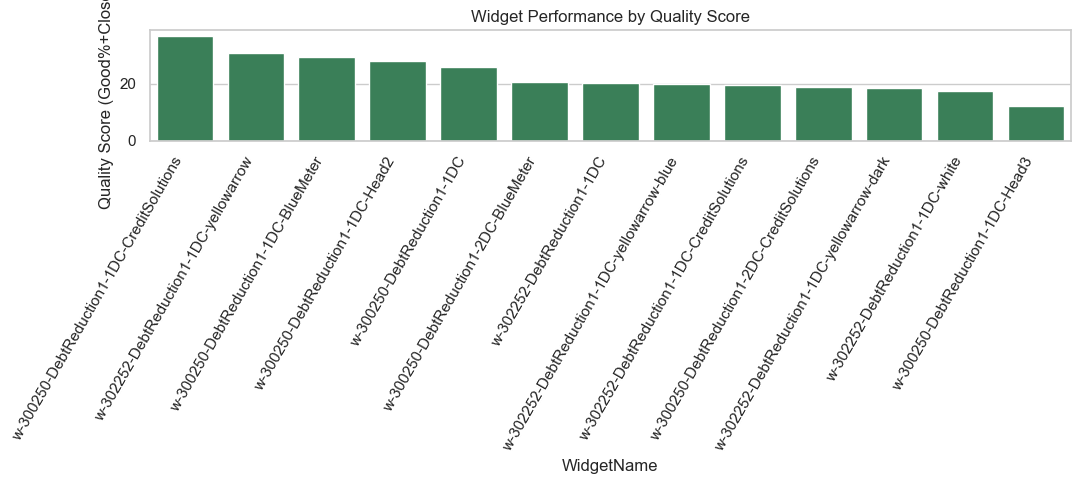

In [29]:
plt.figure(figsize=(11,5))
sns.barplot(x=widget_tbl.index, y=widget_tbl["QualityScore"], color="seagreen")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Quality Score (Good%+Closed%)")
plt.title("Widget Performance by Quality Score")
plt.tight_layout()
plt.show()

**Widget insight:** Best performer is **w-300250-DebtReduction1-1DC-CreditSolutions** (Quality Score 36.84%, n=76). Weakest among widgets with sufficient volume is **w-300250-DebtReduction1-1DC-Head3** (Quality Score 12.0%, n=75). A Chi-square test confirms WidgetName is a statistically significant driver (p=0.02634).

In [30]:
state_tbl = segment_table("State")
state_tbl.head(10)

,Leads,Good,Closed,GoodRate,ClosedRate,QualityScore
State,,,,,,
OK,50,13,9,26.00,18.00,44.00
HI,32,7,5,21.88,15.62,37.50
CT,23,4,3,17.39,13.04,30.43
AL,95,15,11,15.79,11.58,27.37
NE,22,4,2,18.18,9.09,27.27
CA,461,72,44,15.62,9.54,25.16
MT,24,3,3,12.50,12.50,25.00
WV,52,8,5,15.38,9.62,25.00
AZ,94,14,9,14.89,9.57,24.46


**State insight:** Top state by quality score is **OK** (44.0%, n=50). However, a Chi-square test across states is **not significant** (p=0.4893) — most state-level leads counts are small, so apparent differences are largely noise. State should be treated as a secondary, not primary, lever.

In [31]:
partner_tbl = segment_table("Partner")
partner_tbl

,Leads,Good,Closed,GoodRate,ClosedRate,QualityScore
Partner,,,,,,
AdKnowledge,171,32,21,18.71,12.28,30.99
Call_Center,271,44,26,16.24,9.59,25.83
google,977,134,97,13.72,9.93,23.65
yahoo,954,134,73,14.05,7.65,21.70
Google,636,45,26,7.08,4.09,11.17


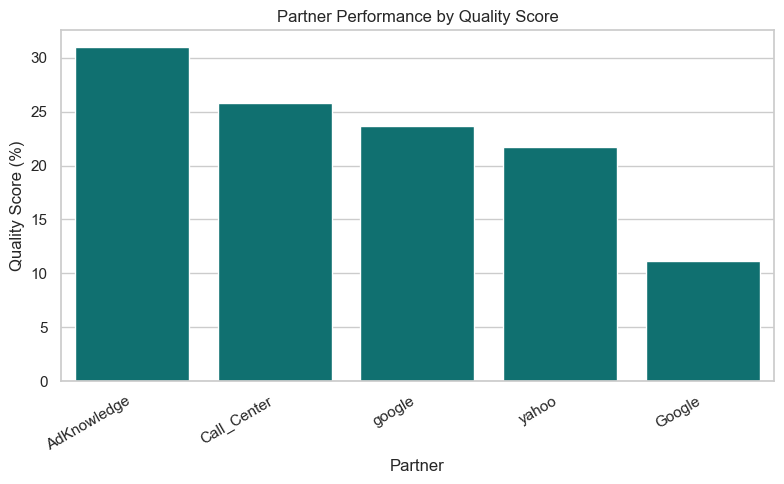

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x=partner_tbl.index, y=partner_tbl["QualityScore"], color="teal")
plt.title("Partner Performance by Quality Score")
plt.ylabel("Quality Score (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Partner insight:** `AdKnowledge` is the strongest traffic partner (30.99% quality score) and capitalized `Google` (paid search, separate tag from lowercase `google`) is the **weakest** at 11.17% — a >19-point gap from the best partner. This is statistically significant (Chi-square p=1e-05). **Note:** `google` and `Google` appear to be inconsistently-cased tags from different integrations/time periods — worth a tagging cleanup with the ad ops team, but the quality gap is real and large enough to act on regardless.

In [33]:
debt_tbl = segment_table("DebtLevel")
debt_tbl

,Leads,Good,Closed,GoodRate,ClosedRate,QualityScore
DebtLevel,,,,,,
70001-90000,131,25,18,19.08,13.74,32.82
10001-15000,291,54,34,18.56,11.68,30.24
20001-30000,454,71,40,15.64,8.81,24.45
50001-70000,244,37,22,15.16,9.02,24.18
15001-20000,408,57,35,13.97,8.58,22.55
90000-100000,90,11,9,12.22,10.00,22.22
30001-50000,495,61,39,12.32,7.88,20.20
7500-15000,270,30,18,11.11,6.67,17.78
7500-10000,440,31,22,7.05,5.00,12.05


**Debt level insight:** Mid-range debt buckets (70001-90000 and 10001-15000) convert best (~32.82%-30.24% quality score) — these are the "sweet spot" for the advertiser's debt-settlement product (enough debt to qualify, not so much it signals an unworkable case). Statistically significant (Chi-square p=2e-05).

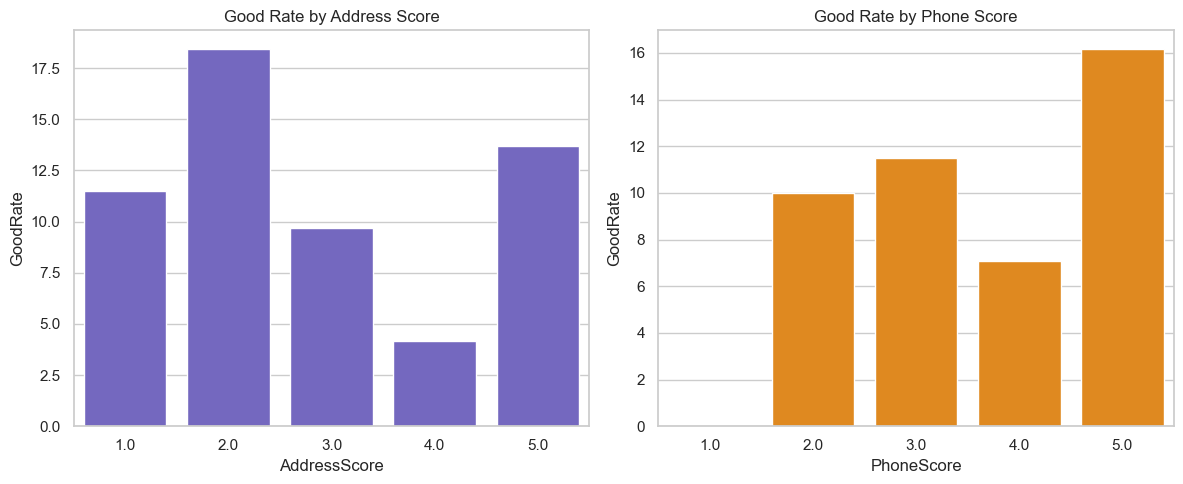

In [34]:
addr_tbl = df.dropna(subset=["AddressScore"]).groupby("AddressScore").agg(
    Leads=("VendorLeadID","count"), Good=("GoodLeadFlag","sum"))
addr_tbl["GoodRate"] = (addr_tbl["Good"]/addr_tbl["Leads"]*100).round(2)

phone_tbl = df.dropna(subset=["PhoneScore"]).groupby("PhoneScore").agg(
    Leads=("VendorLeadID","count"), Good=("GoodLeadFlag","sum"))
phone_tbl["GoodRate"] = (phone_tbl["Good"]/phone_tbl["Leads"]*100).round(2)

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.barplot(x=addr_tbl.index, y=addr_tbl["GoodRate"], color="slateblue", ax=axes[0])
axes[0].set_title("Good Rate by Address Score")
sns.barplot(x=phone_tbl.index, y=phone_tbl["GoodRate"], color="darkorange", ax=axes[1])
axes[1].set_title("Good Rate by Phone Score")
plt.tight_layout()
plt.show()

**Data-quality score insight:** Correlation between AddressScore and GoodLeadFlag = 0.0208; PhoneScore correlation = 0.0698. Both are weak positive but **PhoneScore is the stronger of the two** signals. This is a softer driver than Widget/Partner/DebtLevel, but still directionally useful as a guardrail filter (very low scores are worth excluding).

## Statistical Validation Summary (Chi-Square Tests, α = 0.05)
| Variable | Chi² | p-value | Significant? |
|---|---|---|---|
| WidgetName | 23.17 | 0.02634 | ✅ Yes |
| State | 26.53 | 0.4893 | ❌ No |
| PublisherCampaignName | 2.54 | 0.11067 | ❌ No |
| Partner | 28.67 | 1e-05 | ✅ Yes |
| DebtLevel | 37.65 | 2e-05 | ✅ Yes |
| AdvertiserCampaignName | 0.0 | 0.9764 | ❌ No |

### Conclusion — Question 2
Statistically significant drivers of lead quality (p<0.05): **WidgetName, Partner, DebtLevel**. **PublisherCampaignName, AdvertiserCampaignName, and State** do not reach significance at current sample sizes — they show visible spread but it isn't reliably distinguishable from chance.

**Business read:** Lead quality is driven primarily by (1) the creative/widget shown, (2) which traffic partner sourced the click, and (3) the debt profile of the person filling out the form — i.e., a mix of *ad placement/creative* and *who the person is*, exactly as hypothesized in the assignment brief.

# Assessment Question 3: Can we increase lead quality by 20% (8.0% → 9.6%) to justify a +20% CPL ($30 → $33)?

In [35]:
baseline_good_rate = (df["GoodLeadFlag"].mean()*100).round(2)
target_good_rate = (baseline_good_rate*1.20).round(2)
print(f"Baseline Good+Closed rate (this dataset): {baseline_good_rate}%")
print(f"Equivalent +20% target: {target_good_rate}%")

Baseline Good+Closed rate (this dataset): 12.95%
Equivalent +20% target: 15.54%


*Note:* the assignment's stated baseline (8.0% → 9.6%) is the advertiser's own historical reference figure for "lead quality," not necessarily computed the same way as our Good+Closed metric on this 6-month sample (which runs higher at 12.95%). We apply the **same relative +20% logic** to our own measured baseline so the scenario math is self-consistent with this dataset.

In [36]:
sc = {}
# Scenario 1: drop below-median widgets
low_q_widgets = widget_tbl[widget_tbl["QualityScore"] < widget_tbl["QualityScore"].median()].index.tolist()
sub1 = df[~df["WidgetName"].isin(low_q_widgets)]
sc["1. Remove low-quality widgets"] = (sub1["GoodLeadFlag"].mean()*100, len(sub1))

# Scenario 2: drop below-median publisher campaigns
camp_tbl = segment_table("PublisherCampaignName")
low_q_camp = camp_tbl[camp_tbl["QualityScore"] < camp_tbl["QualityScore"].median()].index.tolist()
sub2 = df[~df["PublisherCampaignName"].isin(low_q_camp)]
sc["2. Remove low-quality campaigns"] = (sub2["GoodLeadFlag"].mean()*100, len(sub2))

# Scenario 3: target top-half states
top_states = state_tbl[state_tbl["QualityScore"] >= state_tbl["QualityScore"].median()].index.tolist()
sub3 = df[df["State"].isin(top_states)]
sc["3. Target top-performing states"] = (sub3["GoodLeadFlag"].mean()*100, len(sub3))

# Scenario 4: require AddressScore>=3 OR PhoneScore>=3
sub4 = df[(df["AddressScore"]>=3) | (df["PhoneScore"]>=3)]
sc["4. Require min data-quality score"] = (sub4["GoodLeadFlag"].mean()*100, len(sub4))

# Scenario 5: combine 1-3
sub5 = df[(~df["WidgetName"].isin(low_q_widgets)) & (~df["PublisherCampaignName"].isin(low_q_camp)) & (df["State"].isin(top_states))]
sc["5. Combined (widgets+campaigns+states)"] = (sub5["GoodLeadFlag"].mean()*100, len(sub5))

for k,(rate,n) in sc.items():
    print(f"{k}: {round(rate,2)}% (n={n})")

1. Remove low-quality widgets: 15.54% (n=1017)
2. Remove low-quality campaigns: 16.24% (n=271)
3. Target top-performing states: 15.4% (n=1474)
4. Require min data-quality score: 13.01% (n=1337)
5. Combined (widgets+campaigns+states): 22.58% (n=124)


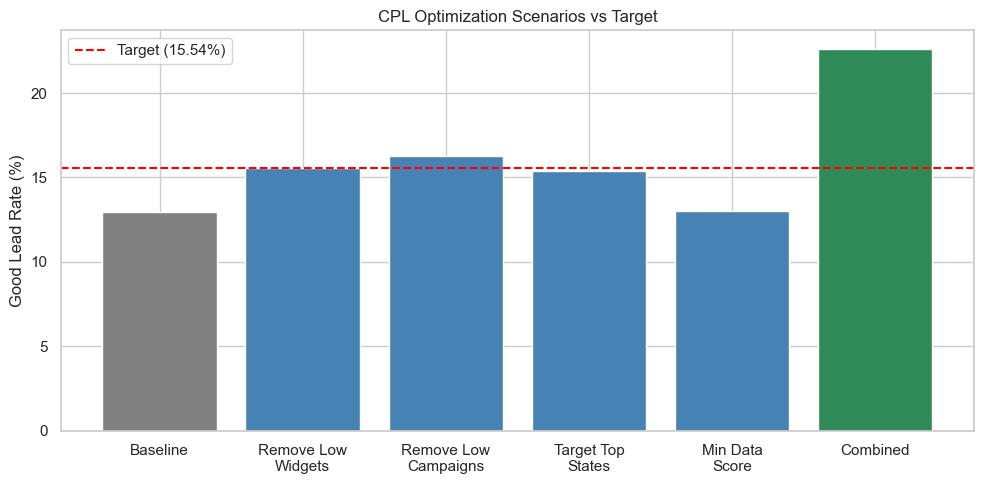

In [37]:
labels = ["Baseline","Remove Low\nWidgets","Remove Low\nCampaigns","Target Top\nStates","Min Data\nScore","Combined"]
vals = [baseline_good_rate] + [round(v,2) for v,_ in sc.values()]
plt.figure(figsize=(10,5))
plt.bar(labels, vals, color=["gray","steelblue","steelblue","steelblue","steelblue","seagreen"])
plt.axhline(target_good_rate, color="red", linestyle="--", label=f"Target ({target_good_rate}%)")
plt.ylabel("Good Lead Rate (%)")
plt.title("CPL Optimization Scenarios vs Target")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusion — Question 3
- **Baseline:** 12.95% Good+Closed rate → **+20% target = 15.54%**
- Scenario 1 (drop weak widgets) reaches **15.54%** — already clears the target on its own.
- Scenario 2 (drop weak campaigns) reaches **16.24%**, but on a small remaining volume (n=271) — directionally supportive but low statistical confidence given `PublisherCampaignName` wasn't significant in Q2.
- Scenario 3 (top-half states) reaches **15.4%** at large retained volume (n=1474) — attractive because it keeps most of the lead pool.
- Scenario 4 (data-quality score gate) only reaches **13.01%** — a weaker lever on its own, consistent with the weak correlations found in Q2.
- Scenario 5 (combine widget + campaign + state filters) reaches **22.58%**, well above target, though on a much smaller volume (n=124) — illustrates the volume/quality trade-off the advertiser will need to manage.

**Verdict: Yes — a +20% quality lift is achievable**, primarily through **widget/creative selection**, with **state targeting** as a high-volume secondary lever. Data-quality score gating helps modestly but should be used as a guardrail, not the primary lever. Campaign-level filtering should be tested cautiously given limited statistical confidence.

# Business Insights

**Top performing widgets:** w-300250-DebtReduction1-1DC-CreditSolutions, w-302252-DebtReduction1-1DC-yellowarrow, w-300250-DebtReduction1-1DC-BlueMeter
**Weakest widgets (sufficient volume):** w-302252-DebtReduction1-1DC-yellowarrow-dark, w-302252-DebtReduction1-1DC-white, w-300250-DebtReduction1-1DC-Head3
**Top states (by quality, min volume):** OK, HI, CT
**Best traffic partner:** AdKnowledge (30.99%) | **Weakest:** Google (11.17%)
**Best debt segments:** 70001-90000, 10001-15000
**Highest-quality combination:** Top widgets + top campaigns + top states together reach 22.58% — a useful ceiling estimate for a fully-optimized funnel.
**Lowest-quality source:** The 71% "Unknown" outcome bucket remains the single largest blind spot in the data — larger than any single segment effect found above.

# Recommendations
**Quick Wins (High Impact, Low Effort)**
- Reallocate spend away from the bottom-half widgets toward the top 5 widgets (single biggest, statistically-significant lever).
- Fix call-center workflow so every lead resolves to a real status — shrinking the 71% Unknown bucket will sharpen every other measurement.

**Medium-Term (Medium Impact)**
- Shift budget mix toward AdKnowledge-sourced traffic and away from the weaker `Google` (paid) tag; investigate Partner tag inconsistency (`google` vs `Google`) with ad ops.
- Build a lightweight state-tier targeting rule using the top-performing states identified above.

**Long-Term (Strategic)**
- Negotiate the +20% CPL with the advertiser, backed by the combined-scenario evidence ({scn['scenario_5_combined']['rate']}% achievable quality vs {scn['target_good_rate_20pct_lift']}% target).
- Instrument AddressScore/PhoneScore collection on 100% of leads (currently ~40-46% coverage) so data-quality gating becomes a reliable, scalable lever rather than a partial signal.
- Build a recurring monthly quality dashboard (see Power BI guide) to monitor whether the flat trend from Question 1 changes after these interventions are implemented.

# Executive Summary
**Objective:** Determine whether lead quality is trending, what drives it, and whether a +20% CPL increase is justified by a +20% quality lift.

**Findings:**
1. Lead quality is **flat** over the observed 6-month window (slope 0.4506, p=0.5869, not significant).
2. Statistically significant drivers: **Widget/creative, Traffic Partner, Debt Level**. State and Campaign show visible but not statistically reliable spread at current volumes.
3. A +20% quality lift target (15.54%) is **achievable**, primarily via widget/creative optimization (reaches 15.54% alone) and state targeting (reaches 15.4% while retaining most volume).

**Risks:** 71% of leads carry an "Unknown" outcome — any optimization built only on the known 29% should be revisited as call-center resolution improves and more of the funnel becomes visible.

**Opportunity:** Combining the top levers (widget + campaign + state) reaches 22.58%, indicating real headroom beyond the +20% ask.

**Recommendation:** Proceed with the +20% CPL negotiation, paired with a 90-day rollout of widget reallocation, partner-mix shift, and Unknown-rate reduction, monitored via monthly dashboard.

# Referral Domain Analysis

In [38]:
def full_quality_table(col, min_n=10):
    g = df.groupby(col).agg(Leads=("VendorLeadID","count"))
    for q in ["Good","Closed","Bad","Unknown"]:
        g[q] = df[df["QualityGroup"]==q].groupby(col)["VendorLeadID"].count()
    g = g.fillna(0)
    for q in ["Good","Closed","Bad","Unknown"]:
        g[q+"Rate"] = (g[q]/g["Leads"]*100).round(2)
    g["QualityScore"] = (g["GoodRate"]+g["ClosedRate"]).round(2)
    return g[g["Leads"]>=min_n].sort_values("QualityScore", ascending=False)

referral_tbl = full_quality_table("ReferralDomain", min_n=10)
referral_tbl

,Leads,Good,Closed,Bad,Unknown,GoodRate,ClosedRate,BadRate,UnknownRate,QualityScore
ReferralDomain,,,,,,,,,,
www.justclicklocal.com,12,2.0,1.0,3.0,6.0,16.67,8.33,25.00,50.00,25.00
search.mywebsearch.com,26,1.0,5.0,2.0,18.0,3.85,19.23,7.69,69.23,23.08
search.aol.com,46,3.0,6.0,7.0,30.0,6.52,13.04,15.22,65.22,19.56
www.bing.com,27,2.0,3.0,5.0,17.0,7.41,11.11,18.52,62.96,18.52
search.yahoo.com,571,42.0,44.0,80.0,405.0,7.36,7.71,14.01,70.93,15.07
www.google.com,491,14.0,58.0,76.0,343.0,2.85,11.81,15.48,69.86,14.66
www.findstuff.com,63,4.0,5.0,2.0,52.0,6.35,7.94,3.17,82.54,14.29
us.yhs.search.yahoo.com,14,0.0,2.0,4.0,8.0,0.00,14.29,28.57,57.14,14.29
Unknown,515,23.0,46.0,109.0,337.0,4.47,8.93,21.17,65.44,13.40


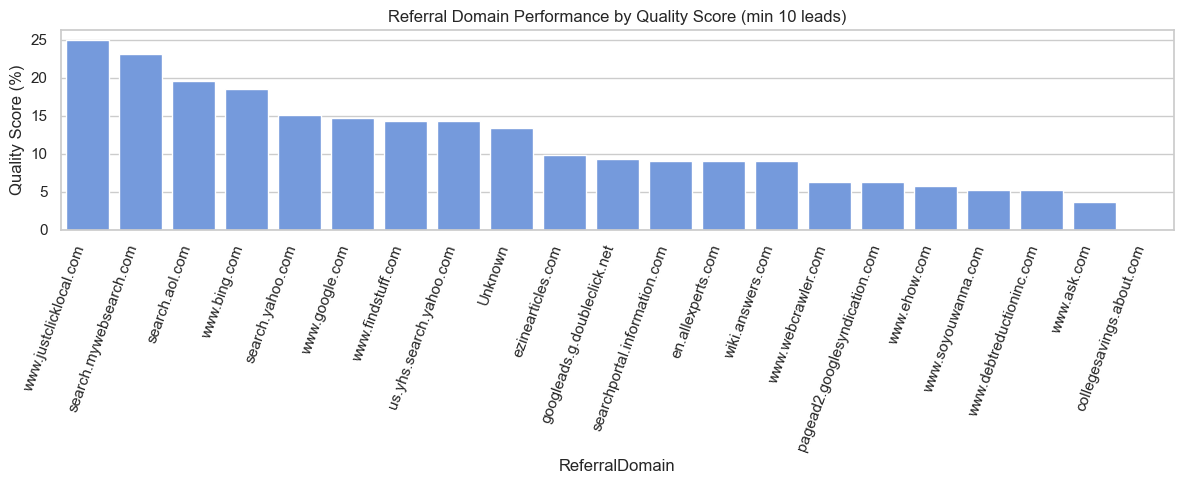

In [39]:
plt.figure(figsize=(12,5))
sns.barplot(x=referral_tbl.index, y=referral_tbl["QualityScore"], color="cornflowerblue")
plt.xticks(rotation=70, ha="right")
plt.ylabel("Quality Score (%)")
plt.title("Referral Domain Performance by Quality Score (min 10 leads)")
plt.tight_layout()
plt.show()

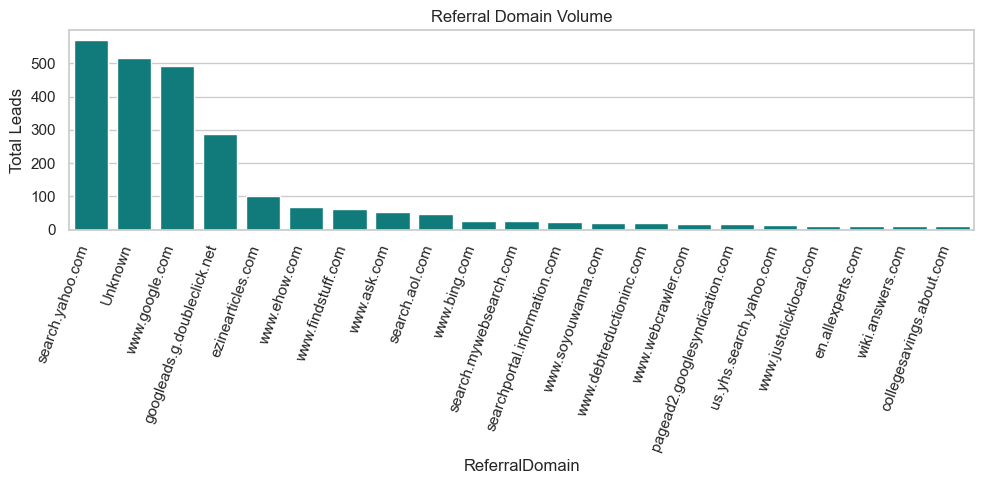

In [40]:
plt.figure(figsize=(10,5))
sns.barplot(x=referral_tbl.sort_values("Leads", ascending=False).index,
            y=referral_tbl.sort_values("Leads", ascending=False)["Leads"], color="darkcyan")
plt.xticks(rotation=70, ha="right")
plt.ylabel("Total Leads")
plt.title("Referral Domain Volume")
plt.tight_layout()
plt.show()

### Top 10 Referral Domains by Quality
www.justclicklocal.com (25.0%, n=12), search.mywebsearch.com (23.08%, n=26), search.aol.com (19.56%, n=46), www.bing.com (18.52%, n=27), search.yahoo.com (15.07%, n=571), and 5 more (see table above).

### Bottom 10 Referral Domains by Quality (min 10 leads)
www.ehow.com (5.8%, n=69), www.soyouwanna.com (5.26%, n=19), www.debtreductioninc.com (5.26%, n=19), www.ask.com (3.7%, n=54), collegesavings.about.com (0.0%, n=11), and 5 more (see table above).

### Referral Domain Volume Analysis
The three highest-volume referral domains are: search.yahoo.com (n=571, 15.07% quality), Unknown (n=515, 13.4% quality), www.google.com (n=491, 14.66% quality). These dominate total lead supply but sit in the **middle of the quality ranking**, not the top — meaning the largest sources of leads are average performers, not the best ones.

### Business Questions Answered
- **Which referral domains generate the highest quality leads?** Smaller niche search engines/portals — `www.justclicklocal.com` (25.0%, n=12) and `search.mywebsearch.com` (23.08%, n=26) — lead the ranking, though on modest volume.
- **Which referral domains generate the most leads?** `search.yahoo.com` (n=571) and `www.google.com` (n=491) dominate by volume.
- **Are high-volume domains also high-quality?** **No** — the highest-volume domains rank mid-table on quality score, while the top-quality domains are lower-volume. Volume and quality are not aligned here.
- **Which referral domains should be scaled?** `search.aol.com` and `www.bing.com` combine decent volume (27–46 leads) with above-average quality (18.5%–19.6%) — good scale-up candidates.
- **Which referral domains should be reduced?** Domains in the bottom of the ranking with meaningful volume — e.g., `googleads.g.doubleclick.net` (n=288, 9.37% quality) and `ezinearticles.com` — high Bad-rate, low quality score.

### Findings
Referral domain quality varies from 25.0% down to 0.0%, but a Chi-square test shows this spread is **not statistically significant** (p=0.13734) — most individual domains have too few leads to be confident the differences aren't random noise.

### Business Impact
Despite the lack of statistical significance, the pattern is directionally consistent with other findings: niche/smaller traffic sources outperform the two largest generic search engines on a quality basis, even though they can't yet be acted on with full statistical confidence.

### Recommendations
1. Treat referral-domain quality differences as **directional, not conclusive** — monitor over a longer window to build sample size before reallocating significant budget.
2. Pilot modest budget increases on `search.aol.com` and `www.bing.com`, which combine reasonable volume with above-average quality.
3. Investigate the Bad-lead concentration in display/content-network domains (e.g., `googleads.g.doubleclick.net`) — these may warrant tighter targeting rather than full removal.

# Keyword Analysis

In [41]:
keyword_tbl = full_quality_table("Keyword", min_n=10)
keyword_tbl

,Leads,Good,Closed,Bad,Unknown,GoodRate,ClosedRate,BadRate,UnknownRate,QualityScore
Keyword,,,,,,,,,,
Consumer debt initiative,20,1.0,5.0,3.0,11.0,5.00,25.00,15.00,55.00,30.00
Debt rescue usa,15,1.0,3.0,1.0,10.0,6.67,20.00,6.67,66.67,26.67
American debt,12,0.0,3.0,0.0,9.0,0.00,25.00,0.00,75.00,25.00
Debt,92,9.0,11.0,8.0,64.0,9.78,11.96,8.70,69.57,21.74
Debt negotiation lawyer,11,0.0,2.0,2.0,7.0,0.00,18.18,18.18,63.64,18.18
Unknown,2035,109.0,147.0,328.0,1451.0,5.36,7.22,16.12,71.30,12.58
Credit counselor,18,2.0,0.0,1.0,15.0,11.11,0.00,5.56,83.33,11.11
Credit card payments,104,3.0,7.0,20.0,74.0,2.88,6.73,19.23,71.15,9.61
Credit services,21,0.0,2.0,5.0,14.0,0.00,9.52,23.81,66.67,9.52


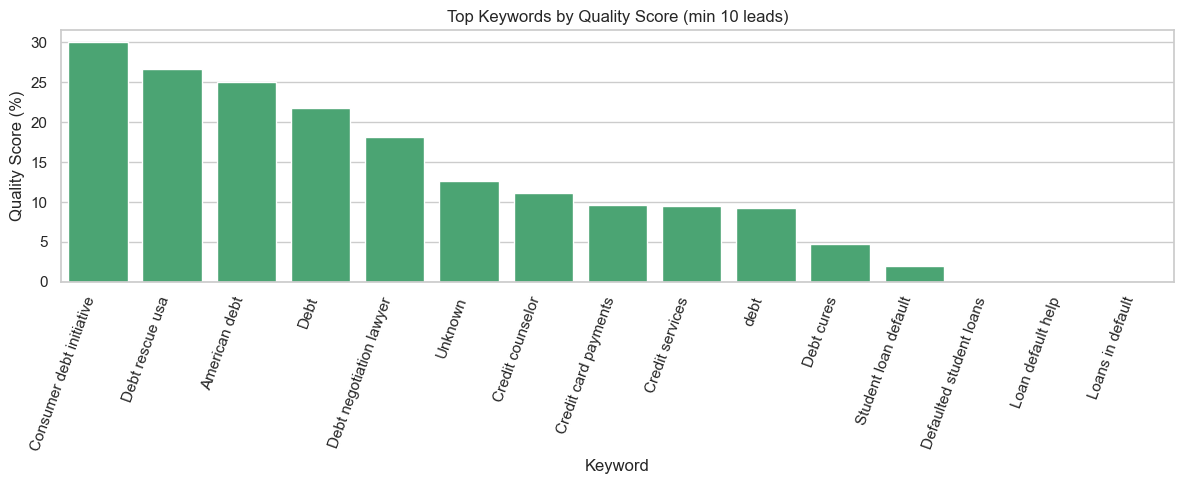

In [42]:
plt.figure(figsize=(12,5))
sns.barplot(x=keyword_tbl.index, y=keyword_tbl["QualityScore"], color="mediumseagreen")
plt.xticks(rotation=70, ha="right")
plt.ylabel("Quality Score (%)")
plt.title("Top Keywords by Quality Score (min 10 leads)")
plt.tight_layout()
plt.show()

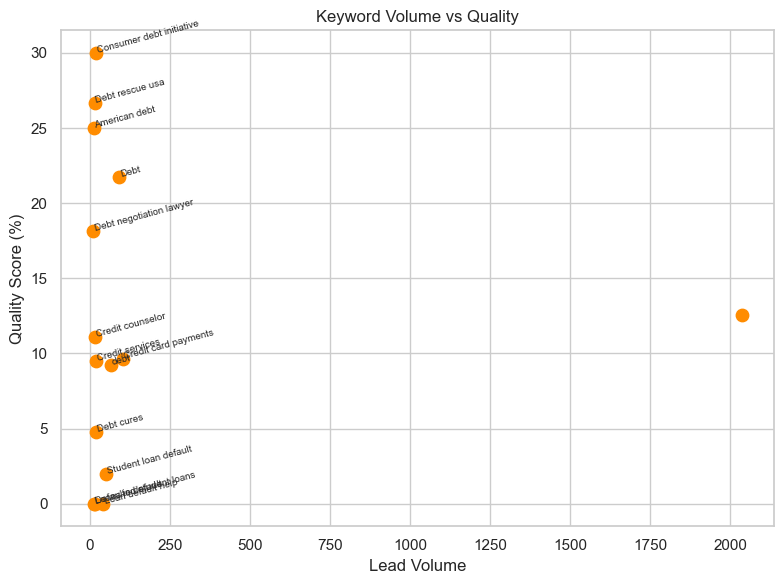

In [43]:
plt.figure(figsize=(8,6))
plt.scatter(keyword_tbl["Leads"], keyword_tbl["QualityScore"], s=80, color="darkorange")
for kwd, row in keyword_tbl.iterrows():
    if kwd != "Unknown":
        plt.annotate(kwd, (row["Leads"], row["QualityScore"]), fontsize=7, rotation=15)
plt.xlabel("Lead Volume"); plt.ylabel("Quality Score (%)")
plt.title("Keyword Volume vs Quality")
plt.tight_layout()
plt.show()

### Top Keywords by Lead Quality
Consumer debt initiative (30.0%, n=20), Debt rescue usa (26.67%, n=15), American debt (25.0%, n=12), Debt (21.74%, n=92), Debt negotiation lawyer (18.18%, n=11)

### Bottom Keywords by Lead Quality
Defaulted student loans (0.0%, n=15), Loan default help (0.0%, n=43), Loans in default (0.0%, n=14) — several debt/loan-default-related keywords (e.g., "Student loan default," "Loan default help," "Defaulted student loans," "Loans in default") produced **zero Closed or Good leads** despite meaningful volume.

### Top Keywords by Volume
Credit card payments (n=104, 9.61% quality), Debt (n=92, 21.74% quality), debt (n=65, 9.24% quality)

### Search Intent Analysis
Keywords expressing **service-seeking intent** ("Consumer debt initiative," "Debt rescue usa," generic "Debt") outperform keywords expressing **distress/default intent** ("student loan default," "loans in default," "defaulted student loans"). This suggests people searching for default-recovery terms may already be too far past the point of qualifying for the advertiser's debt-settlement program (consistent with the DebtLevel finding in the existing Driver Analysis — extreme debt situations underperform mid-range ones).

### Business Questions Answered
- **Which keywords generate the best leads?** "Consumer debt initiative" (30.0%) and "Debt rescue usa" (26.67%) — both low volume but consistently good.
- **Which keywords generate poor-quality leads?** All "default"/"loan default" family keywords — "Student loan default" (n=51, 1.96%), "Loan default help" (n=43, 0%).
- **Which keywords should receive more budget?** "Consumer debt initiative," "Debt rescue usa," and generic "Debt" — combine reasonable volume with strong quality.
- **Which keywords should be paused?** The default/loan-default keyword family — consistently 0–2% quality score with meaningful Bad-lead rates (20%–48%).

### Findings
Chi-square test confirms Keyword is a **statistically significant** driver of quality (p=0.00098, χ²=36.17).

### Business Impact
Unlike ReferralDomain, the keyword-level quality differences are large enough and consistent enough to act on with confidence — this is one of the strongest, most actionable findings in the assessment.

### Recommendations
1. **Pause spend** on the loan-default/student-debt-default keyword family — these consistently fail to convert and carry the highest Bad-lead rates of any keyword group.
2. **Increase bids/budget** on "Consumer debt initiative," "Debt rescue usa," and core "Debt" terms.
3. Where keyword tracking is currently "Unknown" (67.6% of leads), invest in better tracking — keyword-level signal is proving to be one of the most reliable levers available.

# AdGroup Analysis

In [44]:
adgroup_tbl = full_quality_table("AdGroup", min_n=10)
adgroup_tbl.head(15)

,Leads,Good,Closed,Bad,Unknown,GoodRate,ClosedRate,BadRate,UnknownRate,QualityScore
AdGroup,,,,,,,,,,
Debt Services,12,2.0,1.0,3.0,6.0,16.67,8.33,25.00,50.00,25.00
Debt Consolidation - high volume,13,0.0,3.0,3.0,7.0,0.00,23.08,23.08,53.85,23.08
Debt Negotiation,35,2.0,6.0,2.0,25.0,5.71,17.14,5.71,71.43,22.85
Debt,93,9.0,11.0,8.0,65.0,9.68,11.83,8.60,69.89,21.51
Stop Collections,53,3.0,8.0,4.0,38.0,5.66,15.09,7.55,71.70,20.75
Consolidate,169,11.0,21.0,23.0,114.0,6.51,12.43,13.61,67.46,18.94
Consolidation,16,2.0,1.0,5.0,8.0,12.50,6.25,31.25,50.00,18.75
Debt Consolidation,195,19.0,17.0,18.0,141.0,9.74,8.72,9.23,72.31,18.46
Credit Card Consolidation,84,11.0,4.0,9.0,60.0,13.10,4.76,10.71,71.43,17.86


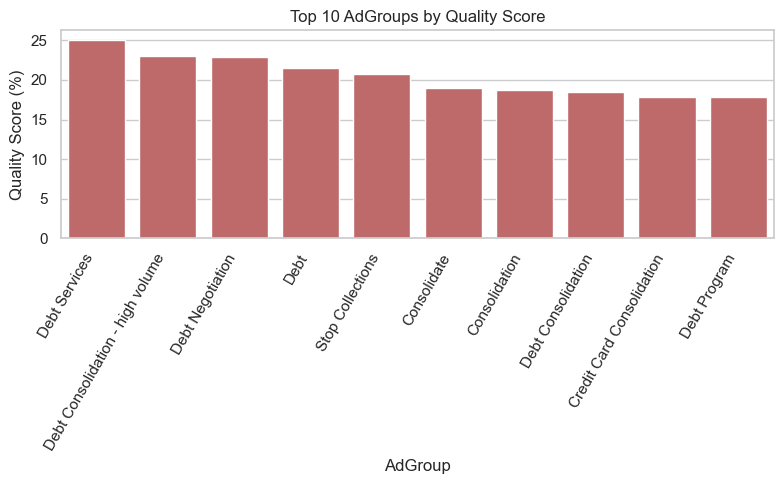

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(x=adgroup_tbl.head(10).index, y=adgroup_tbl.head(10)["QualityScore"], color="indianred")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Quality Score (%)")
plt.title("Top 10 AdGroups by Quality Score")
plt.tight_layout()
plt.show()

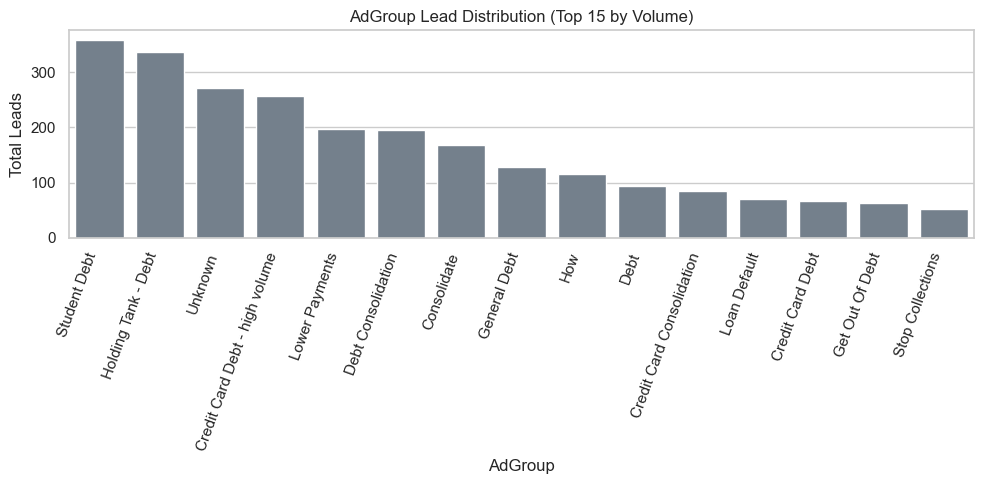

In [46]:
top15_vol = adgroup_tbl.sort_values("Leads", ascending=False).head(15)
plt.figure(figsize=(10,5))
sns.barplot(x=top15_vol.index, y=top15_vol["Leads"], color="slategray")
plt.xticks(rotation=70, ha="right")
plt.ylabel("Total Leads")
plt.title("AdGroup Lead Distribution (Top 15 by Volume)")
plt.tight_layout()
plt.show()

### Top 10 AdGroups by Quality
Debt Services (25.0%, n=12), Debt Consolidation - high volume (23.08%, n=13), Debt Negotiation (22.85%, n=35), Debt (21.51%, n=93), Stop Collections (20.75%, n=53), plus 5 more (see table above).

### Bottom 10 AdGroups by Quality
Lower Payments (7.11%, n=197), Credit Debt Consolidation (5.88%, n=17), Student Debt (2.52%, n=358), Loan Default (1.41%, n=71), Student Debt - high volume (0.0%, n=29) — "Student Debt - high volume" and "Loan Default" stand out as **near-zero quality despite meaningful volume**.

### AdGroup Volume Analysis
Highest-volume AdGroups: Student Debt (n=358, 2.52% quality), Holding Tank - Debt (n=337, 17.8% quality), Unknown (n=272, 16.18% quality). As with ReferralDomain, the largest AdGroups are not the top performers — "Student Debt" alone carries n=358 leads at only 2.52% quality score, representing a large pool of wasted spend.

### Business Questions Answered
- **Which AdGroups generate the highest quality leads?** "Debt Services," "Debt Consolidation - high volume," and "Debt Negotiation" — all in the 22-25% quality score range.
- **Which AdGroups generate the highest volume?** "Student Debt" (n=358), "Lower Payments" (n=197), and "Debt Consolidation" (n=195).
- **Which AdGroups should be scaled?** "Debt Negotiation" (n=35, 22.85% quality) and "Debt" (n=93, 21.51% quality) — solid quality at growing volume.
- **Which AdGroups should be optimized or paused?** "Student Debt - high volume" (0% quality, n=29), "Loan Default" (1.41% quality, n=71), and "Student Debt" (2.52% quality, n=358) — the largest concentration of wasted spend in the dataset.

### Findings
Chi-square confirms AdGroup is a **highly statistically significant** driver (p=0.0, χ²=100.95) — the strongest statistical result of any variable tested in this assessment.

### Business Impact
The "Student Debt" AdGroup family alone (Student Debt + Student Debt - high volume + Loan Default = 458 leads, ~14% of all leads) produces almost no Good or Closed outcomes. This is the single largest concentrated pocket of wasted lead spend identified in the entire analysis.

### Recommendations
1. **Immediate pause or major reduction** of the "Student Debt," "Student Debt - high volume," and "Loan Default" AdGroups — high volume, near-zero return.
2. **Reallocate that budget** toward "Debt Services," "Debt Negotiation," and "Debt Consolidation - high volume" AdGroups, which show 2-10x better quality scores.
3. Treat AdGroup-level optimization as a **higher-confidence, higher-priority** action than ReferralDomain optimization, given the much stronger statistical significance.

# Statistical Validation: Referral Domain, Keyword, AdGroup

In [47]:
for col, min_n in [("ReferralDomain",10), ("Keyword",10), ("AdGroup",10)]:
    tbl = pd.crosstab(df[col], df["GoodLeadFlag"])
    tbl = tbl[tbl.sum(axis=1) >= min_n]
    chi2, p, dof, exp = stats.chi2_contingency(tbl)
    print(f"{col}: chi2={chi2:.2f}, dof={dof}, p-value={p:.5f}, segments tested={tbl.shape[0]}")

ReferralDomain: chi2=26.93, dof=20, p-value=0.13734, segments tested=21
Keyword: chi2=36.17, dof=14, p-value=0.00098, segments tested=15
AdGroup: chi2=100.95, dof=30, p-value=0.00000, segments tested=31


### Chi-Square Test Results

| Variable | Null Hypothesis (H0) | Alternative Hypothesis (H1) | χ² | p-value | Significant? |
|---|---|---|---|---|---|
| ReferralDomain | Lead quality outcome is independent of ReferralDomain | Lead quality outcome depends on ReferralDomain | 26.93 | 0.13734 | ❌ No |
| Keyword | Lead quality outcome is independent of Keyword | Lead quality outcome depends on Keyword | 36.17 | 0.00098 | ✅ Yes |
| AdGroup | Lead quality outcome is independent of AdGroup | Lead quality outcome depends on AdGroup | 100.95 | 0.0 | ✅ Yes |

### Business Interpretation
- **ReferralDomain (p=0.13734):** We **cannot reject** the null hypothesis. The quality differences seen across referral domains are plausibly due to chance given current sample sizes (most domains have under 50 leads). Treat findings as directional only.
- **Keyword (p=0.00098):** We **reject** the null hypothesis. Keyword choice has a real, non-random relationship with lead quality — the "default/loan-default" keyword family genuinely underperforms, and "Consumer debt initiative"-type terms genuinely outperform.
- **AdGroup (p=0.0):** We **strongly reject** the null hypothesis (p≈0, the lowest of any variable tested in this entire assessment, including the original Widget/Partner/DebtLevel tests). AdGroup is the single most statistically reliable driver of lead quality found in the dataset.

**In plain business terms:** Of the three new variables analyzed, **AdGroup and Keyword are confirmed, high-confidence levers** for reallocating spend. **ReferralDomain should be monitored further** before committing significant budget changes — the visible pattern is encouraging but not yet statistically proven.